<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

Размеры окон: M1=31, M2=51
Теоретическое sigma после свёртки: 5.830952
RMSE между численным и аналитическим результатами: 1.55e-08


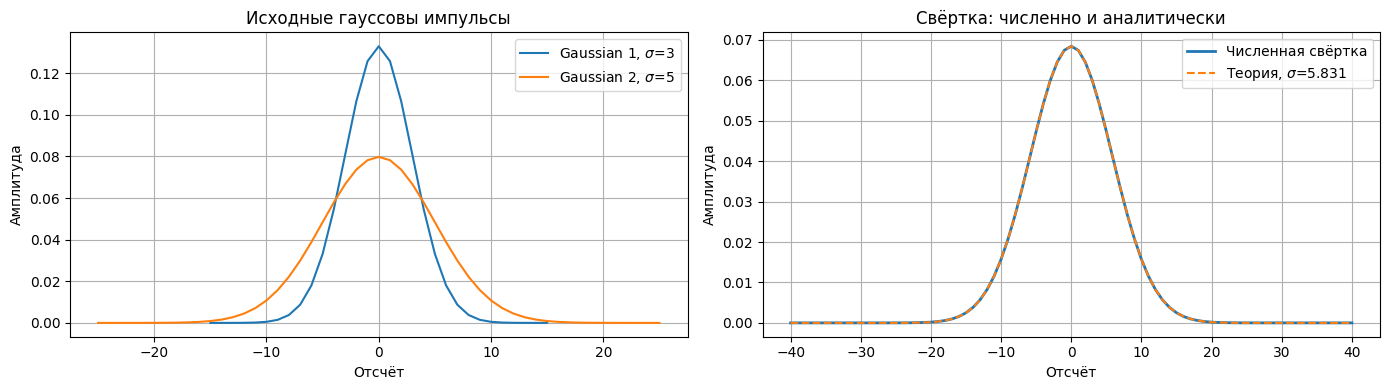

In [2]:
sigma1, sigma2 = 3, 5
M1 = int(np.ceil(10 * sigma1)) | 1
M2 = int(np.ceil(10 * sigma2)) | 1

x1 = np.arange(M1) - (M1 - 1) / 2
x2 = np.arange(M2) - (M2 - 1) / 2

g1 = signal.windows.gaussian(M1, std=sigma1)
g2 = signal.windows.gaussian(M2, std=sigma2)
g1 /= g1.sum()
g2 /= g2.sum()

conv_num = np.convolve(g1, g2, mode='full')
x_conv = np.arange(len(conv_num)) - ((M1 - 1) / 2 + (M2 - 1) / 2)

sigma_theory = np.sqrt(sigma1 ** 2 + sigma2 ** 2)
g_theory = np.exp(-0.5 * (x_conv / sigma_theory) ** 2)
g_theory /= g_theory.sum()

rmse = np.sqrt(np.mean((conv_num - g_theory) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(x1, g1, label=f'Gaussian 1, $\\sigma$={sigma1}')
axes[0].plot(x2, g2, label=f'Gaussian 2, $\\sigma$={sigma2}')
axes[0].set_title('Исходные гауссовы импульсы')
axes[0].set_xlabel('Отсчёт')
axes[0].set_ylabel('Амплитуда')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x_conv, conv_num, label='Численная свёртка', linewidth=2)
axes[1].plot(x_conv, g_theory, '--', label=f'Теория, $\\sigma$={sigma_theory:.3f}')
axes[1].set_title('Свёртка: численно и аналитически')
axes[1].set_xlabel('Отсчёт')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

print(f'Размеры окон: M1={M1}, M2={M2}')
print(f'Теоретическое sigma после свёртки: {sigma_theory:.6f}')
print(f'RMSE между численным и аналитическим результатами: {rmse:.2e}')


**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

При увеличении $\sigma$ свёртка становится шире и более гладкой, а её максимум уменьшается.

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

L | rect A(5 Гц) | rect A(80 Гц) | gauss A(5 Гц) | gauss A(80 Гц)
11 | 0.9951 | 0.0678 | 0.9978 | 0.2804
21 | 0.9822 | 0.0800 | 0.9922 | 0.0502
41 | 0.9330 | 0.0367 | 0.9704 | 0.0005
81 | 0.7542 | 0.0254 | 0.8891 | 0.0028


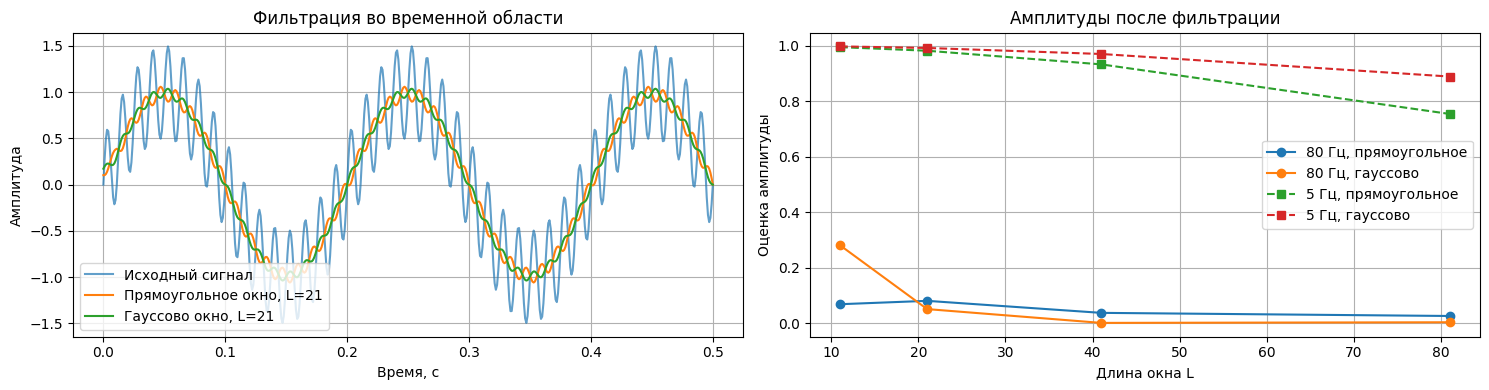

In [3]:
fs = 1000
t = np.arange(0, 2.0, 1 / fs)
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 80 * t)
lengths = [11, 21, 41, 81]


def amplitude_at(x, f):
    spec = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1 / fs)
    i = np.argmin(np.abs(freqs - f))
    return 2 * np.abs(spec[i]) / len(x)


results = []
for L in lengths:
    rect = signal.windows.boxcar(L) / L
    gauss = signal.windows.gaussian(L, std=L / 5)
    gauss /= gauss.sum()
    y_rect = np.convolve(x, rect, mode='same')
    y_gauss = np.convolve(x, gauss, mode='same')
    results.append((L, y_rect, y_gauss, amplitude_at(y_rect, 5), amplitude_at(y_rect, 80), amplitude_at(y_gauss, 5), amplitude_at(y_gauss, 80)))

plot_mask = t <= 0.5
L0, y_rect0, y_gauss0, *_ = next(row for row in results if row[0] == 21)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(t[plot_mask], x[plot_mask], label='Исходный сигнал', alpha=0.7)
axes[0].plot(t[plot_mask], y_rect0[plot_mask], label=f'Прямоугольное окно, L={L0}')
axes[0].plot(t[plot_mask], y_gauss0[plot_mask], label=f'Гауссово окно, L={L0}')
axes[0].set_title('Фильтрация во временной области')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Амплитуда')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(lengths, [row[4] for row in results], 'o-', label='80 Гц, прямоугольное')
axes[1].plot(lengths, [row[6] for row in results], 'o-', label='80 Гц, гауссово')
axes[1].plot(lengths, [row[3] for row in results], 's--', label='5 Гц, прямоугольное')
axes[1].plot(lengths, [row[5] for row in results], 's--', label='5 Гц, гауссово')
axes[1].set_title('Амплитуды после фильтрации')
axes[1].set_xlabel('Длина окна L')
axes[1].set_ylabel('Оценка амплитуды')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

print('L | rect A(5 Гц) | rect A(80 Гц) | gauss A(5 Гц) | gauss A(80 Гц)')
for L, _, _, rect_5, rect_80, gauss_5, gauss_80 in results:
    print(f'{L:>2} | {rect_5:.4f} | {rect_80:.4f} | {gauss_5:.4f} | {gauss_80:.4f}')


**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

При одинаковой длине в этом расчёте гауссово окно обычно лучше: оно сильнее подавляет 80 Гц и лучше сохраняет 5 Гц. Исключение только $L=11$, где прямоугольное окно подавило 80 Гц чуть сильнее.

Падение 80 Гц примерно в 10 раз:
- прямоугольное: с $L=41$;
- гауссово: с $L=21$.

При росте $L$ подавление 80 Гц усиливается, но 5 Гц тоже уменьшается. Падение 5 Гц больше чем на 10% появляется только при $L=81$.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

noise | mean(delay_est) | std(delay_est) | P(|err| > 10) | P(|delay_est| <= 10)
0.0 | 100.00 | 0.00 | 0.00 | 0.00
0.1 | 100.00 | 0.00 | 0.00 | 0.00
0.2 | 100.00 | 0.00 | 0.00 | 0.00
0.3 | 100.00 | 0.00 | 0.00 | 0.00
0.4 | 100.00 | 0.00 | 0.00 | 0.00
0.5 | 100.00 | 0.00 | 0.00 | 0.00
0.6 | 100.01 | 0.10 | 0.00 | 0.00
0.7 | 100.00 | 0.14 | 0.00 | 0.00
0.8 | 100.01 | 0.17 | 0.00 | 0.00
0.9 | 100.02 | 0.24 | 0.00 | 0.00
1.0 | 100.03 | 0.36 | 0.00 | 0.00
1.1 | 100.03 | 0.39 | 0.00 | 0.00
1.2 | 100.06 | 0.42 | 0.00 | 0.00
1.3 | 100.06 | 0.42 | 0.00 | 0.00
1.4 | 100.08 | 0.44 | 0.00 | 0.00
1.5 | 100.10 | 0.48 | 0.00 | 0.00
1.6 | 98.75 | 13.55 | 0.01 | 0.00
1.7 | 98.74 | 13.55 | 0.01 | 0.00
1.8 | 98.40 | 13.89 | 0.02 | 0.00
1.9 | 99.61 | 56.02 | 0.08 | 0.00
2.0 | 96.85 | 59.21 | 0.10 | 0.00
Первые редкие ошибки больше 10% появляются примерно при noise_level = 1.6.
В диапазоне noise_level от 0 до 2 оценка не становится практически неотличимой от 0.


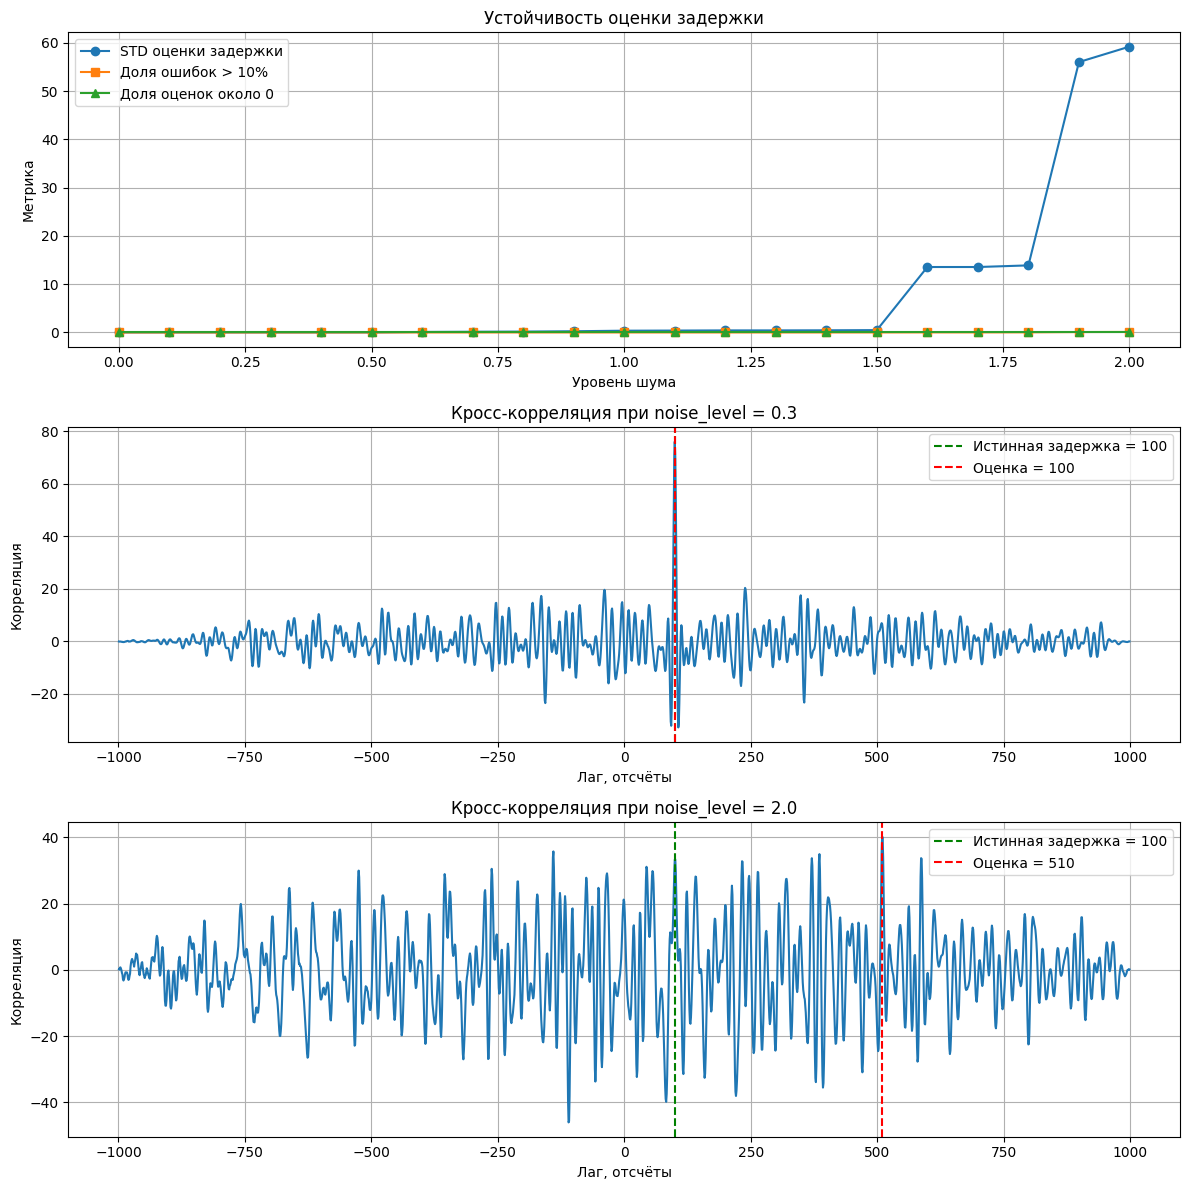

In [4]:
np.random.seed(42)
fs = 1000
t = np.arange(0, 1, 1 / fs)
freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.5, 1.5, 100)
phases = np.random.uniform(0, 2 * np.pi, 100)
x = np.sum(amps[:, None] * np.sin(2 * np.pi * freqs[:, None] * t + phases[:, None]), axis=0)
x /= np.max(np.abs(x))

delay = 100
y_clean = np.r_[x[delay:], np.zeros(delay)]
noise_levels = np.linspace(0, 2, 21)
n_trials = 100
lags = np.arange(-len(x) + 1, len(x))


def estimate_delay(noise_level, seed):
    rng = np.random.default_rng(seed)
    y = y_clean + noise_level * rng.standard_normal(len(x))
    corr = np.correlate(x, y, mode='full')
    delay_est = int(np.argmax(corr) - (len(x) - 1))
    return delay_est, corr


stats = []
for noise in noise_levels:
    estimates = np.array([estimate_delay(noise, 1000 + seed)[0] for seed in range(n_trials)])
    stats.append((noise, estimates.mean(), estimates.std(), np.mean(np.abs(estimates - delay) > 0.1 * delay), np.mean(np.abs(estimates) <= 10)))

example_results = {0.3: estimate_delay(0.3, 1000), 2.0: estimate_delay(2.0, 1036)}

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axes[0].plot(noise_levels, [row[2] for row in stats], 'o-', label='STD оценки задержки')
axes[0].plot(noise_levels, [row[3] for row in stats], 's-', label='Доля ошибок > 10%')
axes[0].plot(noise_levels, [row[4] for row in stats], '^-', label='Доля оценок около 0')
axes[0].set_title('Устойчивость оценки задержки')
axes[0].set_xlabel('Уровень шума')
axes[0].set_ylabel('Метрика')
axes[0].legend()
axes[0].grid(True)

for ax, noise_level in zip(axes[1:], [0.3, 2.0]):
    delay_est, corr = example_results[noise_level]
    ax.plot(lags, corr)
    ax.axvline(delay, color='green', linestyle='--', label=f'Истинная задержка = {delay}')
    ax.axvline(delay_est, color='red', linestyle='--', label=f'Оценка = {delay_est}')
    ax.set_title(f'Кросс-корреляция при noise_level = {noise_level}')
    ax.set_xlabel('Лаг, отсчёты')
    ax.set_ylabel('Корреляция')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

first_bad = next((row[0] for row in stats if row[3] > 0), None)
first_near_zero = next((row[0] for row in stats if row[4] > 0.05), None)

print('noise | mean(delay_est) | std(delay_est) | P(|err| > 10) | P(|delay_est| <= 10)')
for noise, mean_est, std_est, frac_large_error, frac_near_zero in stats:
    print(f'{noise:.1f} | {mean_est:.2f} | {std_est:.2f} | {frac_large_error:.2f} | {frac_near_zero:.2f}')

print(f'Первые редкие ошибки больше 10% появляются примерно при noise_level = {first_bad}.')
if first_near_zero is None:
    print('В диапазоне noise_level от 0 до 2 оценка не становится практически неотличимой от 0.')
else:
    print(f'Оценка становится близкой к 0 примерно при noise_level = {first_near_zero}.')


**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

До `noise_level = 1.5` оценка задержки устойчива и совпадает с истинной. Ошибки больше 10% начинаются при `noise_level = 1.6`.

В диапазоне `0...2` оценка не становится неотличимой от `0`. Ложные пики появляются из-за случайных совпадений, которые создаёт шум.

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

A | SNR, dB | hit rate | mean |error|
0.2 | -22.29 | 0.10 | 211.70
0.4 | -16.26 | 0.10 | 31.65
0.6 | -12.74 | 0.20 | 13.50
0.8 | -10.24 | 0.30 | 3.35
1.0 | -8.31 | 0.40 | 0.70
1.2 | -6.72 | 0.40 | 0.60
1.4 | -5.38 | 0.50 | 0.50
1.6 | -4.22 | 0.55 | 0.45
1.8 | -3.20 | 0.60 | 0.40
2.0 | -2.29 | 0.65 | 0.35
2.2 | -1.46 | 0.75 | 0.25
2.4 | -0.70 | 0.85 | 0.15
2.6 | -0.01 | 0.90 | 0.10
2.8 | 0.64 | 0.90 | 0.10
3.0 | 1.24 | 0.90 | 0.10
3.2 | 1.80 | 0.90 | 0.10
3.4 | 2.32 | 0.95 | 0.05
3.6 | 2.82 | 0.95 | 0.05
3.8 | 3.29 | 1.00 | 0.00
4.0 | 3.74 | 1.00 | 0.00
4.2 | 4.16 | 1.00 | 0.00
4.4 | 4.56 | 1.00 | 0.00
4.6 | 4.95 | 1.00 | 0.00
4.8 | 5.32 | 1.00 | 0.00
5.0 | 5.67 | 1.00 | 0.00


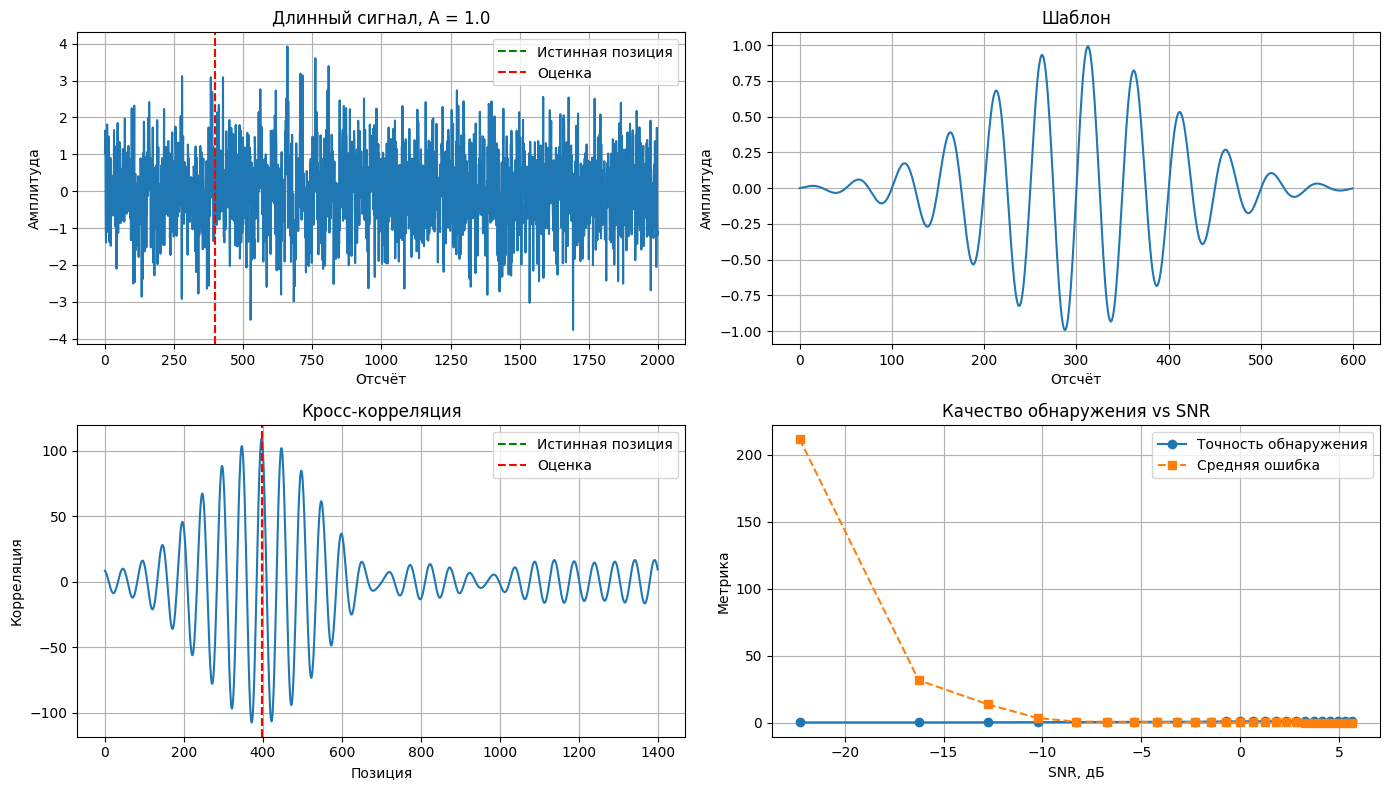

In [5]:
np.random.seed(42)
fs = 1000
sigma = 100
n = np.arange(-3 * sigma, 3 * sigma)
template = np.exp(-0.5 * (n / sigma) ** 2) * np.sin(2 * np.pi * 20 * n / fs)
template_rms = np.sqrt(np.mean(template ** 2))

long_len = 2000
amps = np.linspace(0.2, 5.0, 25)
n_trials = 20
metrics = []

for A in amps:
    errors = []
    for seed in range(n_trials):
        rng = np.random.default_rng(5000 + seed)
        long_signal = rng.standard_normal(long_len)
        insert_pos = int(rng.integers(0, long_len - len(template) + 1))
        long_signal[insert_pos:insert_pos + len(template)] += A * template
        estimate = int(np.argmax(np.correlate(long_signal, template, mode='valid')))
        errors.append(abs(estimate - insert_pos))

    metrics.append((A, 20 * np.log10(A * template_rms), np.mean(np.array(errors) == 0), np.mean(errors)))

example_A = 1.0
rng = np.random.default_rng(2024)
long_signal = rng.standard_normal(long_len)
insert_pos = int(rng.integers(0, long_len - len(template) + 1))
long_signal[insert_pos:insert_pos + len(template)] += example_A * template
corr = np.correlate(long_signal, template, mode='valid')
estimate = int(np.argmax(corr))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(long_signal)
axes[0, 0].axvline(insert_pos, color='green', linestyle='--', label='Истинная позиция')
axes[0, 0].axvline(estimate, color='red', linestyle='--', label='Оценка')
axes[0, 0].set_title(f'Длинный сигнал, A = {example_A}')
axes[0, 0].set_xlabel('Отсчёт')
axes[0, 0].set_ylabel('Амплитуда')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(template)
axes[0, 1].set_title('Шаблон')
axes[0, 1].set_xlabel('Отсчёт')
axes[0, 1].set_ylabel('Амплитуда')
axes[0, 1].grid(True)

axes[1, 0].plot(corr)
axes[1, 0].axvline(insert_pos, color='green', linestyle='--', label='Истинная позиция')
axes[1, 0].axvline(estimate, color='red', linestyle='--', label='Оценка')
axes[1, 0].set_title('Кросс-корреляция')
axes[1, 0].set_xlabel('Позиция')
axes[1, 0].set_ylabel('Корреляция')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot([row[1] for row in metrics], [row[2] for row in metrics], 'o-', label='Точность обнаружения')
axes[1, 1].plot([row[1] for row in metrics], [row[3] for row in metrics], 's--', label='Средняя ошибка')
axes[1, 1].set_title('Качество обнаружения vs SNR')
axes[1, 1].set_xlabel('SNR, дБ')
axes[1, 1].set_ylabel('Метрика')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print('A | SNR, dB | hit rate | mean |error|')
for A, snr_db, hit_rate, mean_abs_error in metrics:
    print(f'{A:.1f} | {snr_db:.2f} | {hit_rate:.2f} | {mean_abs_error:.2f}')


**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

Резкое ухудшение начинается примерно при `SNR ≈ -10...-8 дБ`: ниже этого уровня шум уже часто даёт ложный максимум.

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [6]:
from pathlib import Path

base_url = 'https://raw.githubusercontent.com/korzhimanov/dsp-seminars/main/data'

!mkdir -p data
!wget -q -O data/full_audio.wav {base_url}/full_audio.wav
!wget -q -O data/fragment.wav {base_url}/fragment.wav

full_audio_path = Path('data/full_audio.wav').resolve()
fragment_path = Path('data/fragment.wav').resolve()

print(f'full_audio_path = {full_audio_path}')
print(f'fragment_path = {fragment_path}')


full_audio_path = /home/lucky7788/dsp/dsp-seminars/data/full_audio.wav
fragment_path = /home/lucky7788/dsp/dsp-seminars/data/fragment.wav


Смещение: 279235 отсчётов (6.331859 с)
Коэффициент корреляции между фрагментом и найденным участком: 0.999997
Количество сильных пиков (>= 30% от максимума): 1
Времена сильных пиков, с: [6.332]
IPython.display недоступен, поэтому воспроизведение аудио пропущено.


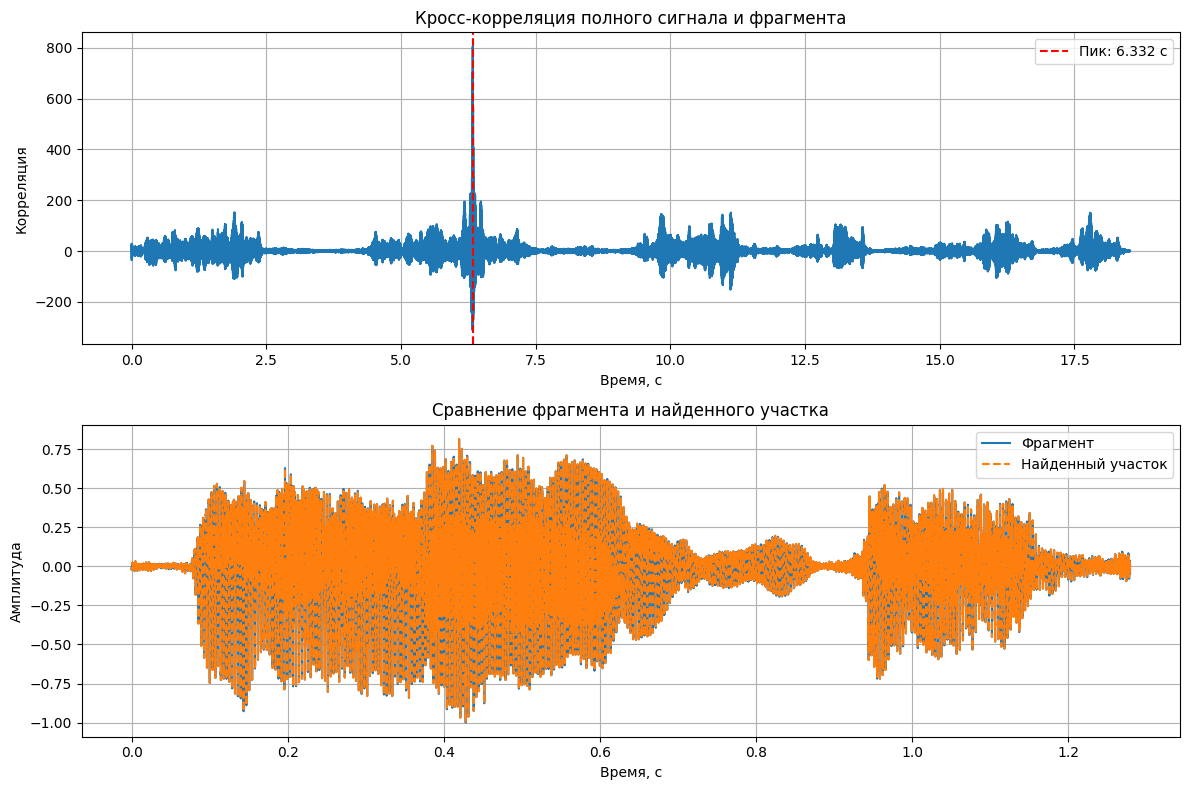

In [7]:
def to_mono_float(data):
    data = data.astype(np.float64)
    data = data.mean(axis=1) if data.ndim == 2 else data
    return data / 32767.0


rate_full, full_audio = wavfile.read(full_audio_path)
rate_frag, fragment = wavfile.read(fragment_path)

full_audio = to_mono_float(full_audio)
fragment = to_mono_float(fragment)

corr = np.correlate(full_audio, fragment, mode='valid')
peak_idx = int(np.argmax(corr))
peak_time = peak_idx / rate_full
matched_fragment = full_audio[peak_idx:peak_idx + len(fragment)].copy()
matched_fragment /= np.max(np.abs(matched_fragment))

match_corr = np.corrcoef(matched_fragment, fragment)[0, 1]
peaks, _ = signal.find_peaks(corr, distance=len(fragment) // 2, height=0.3 * corr.max())

corr_time = np.arange(len(corr)) / rate_full
fragment_time = np.arange(len(fragment)) / rate_frag

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(corr_time, corr)
axes[0].axvline(peak_time, color='red', linestyle='--', label=f'Пик: {peak_time:.3f} с')
axes[0].set_title('Кросс-корреляция полного сигнала и фрагмента')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Корреляция')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(fragment_time, fragment, label='Фрагмент')
axes[1].plot(fragment_time, matched_fragment, '--', label='Найденный участок')
axes[1].set_title('Сравнение фрагмента и найденного участка')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Смещение: {peak_idx} отсчётов ({peak_time:.6f} с)')
print(f'Коэффициент корреляции между фрагментом и найденным участком: {match_corr:.6f}')
print(f'Количество сильных пиков (>= 30% от максимума): {len(peaks)}')
print('Времена сильных пиков, с:', [round(float(p / rate_full), 3) for p in peaks])

display(Audio(fragment, rate=rate_frag))
display(Audio(matched_fragment, rate=rate_full))


**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

Нормализация переводит аудио в диапазон `[-1, 1]` и делает сравнение сигналов корректным по амплитуде.

В этом файле слово встречается `1` раз: найдено одно уверенное совпадение на позиции `279235` отсчётов (`6.331859` с), корреляция `0.999997`.

В этом случае корреляционный анализ находит его уверенно. Ложные максимумы есть, но они заметно слабее главного пика.

Если фрагмента нет, доминирующего пика не будет.